# METR-LA traffic-speed forecasting with STGCN(Cheb)

This self-contained Colab notebook implements **STGCN(Cheb)** from Yu, Yin & Zhu (arXiv:1709.04875). It uses the METR-LA road graph from `adj_METR-LA.pkl`, Chebyshev graph convolution, and GLU-gated temporal convolution. It has no recurrent LSTM component.

## 1. Colab imports, reproducibility, and configuration

Set `DATA_DIR` to the directory containing Kaggle's `METR-LA.h5` and `adj_METR-LA.pkl`.

In [11]:
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils import data
from tqdm.auto import trange

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Change this one visible setting for /content or mounted Google Drive.
DATA_DIR = Path("datasets/metr-la")
# Final comparison artifact: results/model_comparison.csv
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = True
NUM_SENSORS = 207
HORIZON_STEPS = (3, 6, 12)
STGCN_HISTORY_STEPS = 12
DAILY_OFFSET_STEPS = 288
WEEKLY_OFFSET_STEPS = 7 * DAILY_OFFSET_STEPS
PERIODIC_RADIUS = 6
STGCN_BATCH_SIZE = 50
MAX_EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print(f"Selected device: {DEVICE}")
print(f"DATA_DIR: {DATA_DIR}")
print("STGCN(Cheb): blocks=[[1, 32, 64], [64, 32, 128]], Ks=3, Kt=3, RMSProp lr=0.001.")

Selected device: cpu
DATA_DIR: datasets/metr-la
STGCN(Cheb): blocks=[[1, 32, 64], [64, 32, 128]], Ks=3, Kt=3, RMSProp lr=0.001.


## 2. METR-LA and graph loading, sensor alignment, causal missing-value handling, chronological split, and training-only normalization

In [12]:
def _as_sensor_key(value):
    """Match HDF5 columns and adjacency IDs despite bytes/int/string representation."""
    if isinstance(value, bytes):
        value = value.decode()
    return str(value)


def load_adjacency(path: Path):
    with path.open("rb") as handle:
        obj = pickle.load(handle, encoding="latin1")
    if isinstance(obj, (tuple, list)) and len(obj) >= 3:
        sensor_ids, sensor_id_to_ind, adjacency = obj[:3]
    elif isinstance(obj, dict):
        sensor_ids = obj.get("sensor_ids") or obj.get("sensors")
        sensor_id_to_ind = obj.get("sensor_id_to_ind") or obj.get("sensor_id_to_index")
        adjacency = obj.get("adj_mx") if "adj_mx" in obj else obj.get("adjacency")
    else:
        raise ValueError(
            "adj_METR-LA.pkl is not a supported tuple/list or dict-like METR-LA graph."
        )
    if sensor_ids is None or sensor_id_to_ind is None or adjacency is None:
        raise ValueError(
            "adj_METR-LA.pkl must provide sensor_ids, sensor_id_to_ind, and adjacency."
        )
    sensor_ids = list(sensor_ids)
    adjacency = np.asarray(adjacency, dtype=np.float32)
    return sensor_ids, sensor_id_to_ind, adjacency


def read_metr_la_hdf(path: Path):
    """Read standard METR-LA HDF5, including legacy pandas frequency metadata."""
    try:
        return pd.read_hdf(path)
    except TypeError as exc:
        # Some pandas/PyTables combinations reject legacy numpy.bytes_ frequency metadata.
        try:
            import tables
        except ImportError as import_exc:
            raise RuntimeError(
                "Could not read METR-LA.h5; install the standard Colab PyTables dependency."
            ) from import_exc
        try:
            with tables.open_file(path) as handle:
                values = handle.get_node("/df/block0_values").read()
                columns = handle.get_node("/df/block0_items").read()
                timestamps_ns = handle.get_node("/df/axis1").read()
            columns = [_as_sensor_key(column) for column in columns]
            return pd.DataFrame(
                values, index=pd.to_datetime(timestamps_ns), columns=columns
            )
        except Exception as fallback_exc:
            raise RuntimeError(
                f"Unable to read METR-LA HDF5 at {path}: {fallback_exc}"
            ) from exc


data_path = DATA_DIR / "METR-LA.h5"
adj_path = DATA_DIR / "adj_METR-LA.pkl"
if not data_path.is_file():
    raise FileNotFoundError(
        f"METR-LA.h5 is required at {data_path}. Set DATA_DIR to the Kaggle dataset directory."
    )
if not adj_path.is_file():
    raise FileNotFoundError(
        f"STGCN(Cheb) is enabled but adj_METR-LA.pkl is missing at {adj_path}."
    )

speed_frame = read_metr_la_hdf(data_path)
if not isinstance(speed_frame.index, pd.DatetimeIndex):
    speed_frame.index = pd.DatetimeIndex(speed_frame.index)
speed_frame = speed_frame.sort_index()
if speed_frame.shape[1] != NUM_SENSORS:
    raise ValueError(
        f"Expected {NUM_SENSORS} METR-LA sensors, found {speed_frame.shape[1]}."
    )
sensor_ids, sensor_id_to_ind, adjacency = load_adjacency(adj_path)
if len(sensor_ids) != NUM_SENSORS or adjacency.shape != (NUM_SENSORS, NUM_SENSORS):
    raise ValueError(
        f"Expected 207 sensors and (207, 207) adjacency; got {len(sensor_ids)} and {adjacency.shape}."
    )
mapping_by_key = {
    _as_sensor_key(key): int(value) for key, value in sensor_id_to_ind.items()
}
if set(mapping_by_key) != {
    _as_sensor_key(sensor_id) for sensor_id in sensor_ids
} or sorted(mapping_by_key.values()) != list(range(NUM_SENSORS)):
    raise ValueError(
        "sensor_id_to_ind must be a one-to-one mapping onto graph adjacency positions 0..206."
    )
# The adjacency tensor is indexed by sensor_id_to_ind, so put traffic columns into that exact order.
sensor_ids = [
    next(sensor_id for sensor_id in sensor_ids if _as_sensor_key(sensor_id) == key)
    for key, _ in sorted(mapping_by_key.items(), key=lambda pair: pair[1])
]

column_by_key = {_as_sensor_key(c): c for c in speed_frame.columns}
ordered_columns = []
for sensor_id in sensor_ids:
    key = _as_sensor_key(sensor_id)
    if key not in column_by_key:
        raise ValueError(
            f"Graph sensor ID {sensor_id!r} is absent from METR-LA.h5 columns."
        )
    ordered_columns.append(column_by_key[key])
reordering_required = list(speed_frame.columns) != ordered_columns
speed_frame = speed_frame.loc[:, ordered_columns].astype(np.float32)
if speed_frame.shape[1] != NUM_SENSORS or not np.isfinite(adjacency).all():
    raise ValueError("METR-LA sensor/adjacency validation failed.")
print("METR-LA alignment validation")
print(f"  data shape: {speed_frame.shape}")
print(f"  timestamp range: {speed_frame.index.min()} to {speed_frame.index.max()}")
print(f"  sensors: {speed_frame.shape[1]}")
print(f"  adjacency shape: {adjacency.shape}")
print(f"  reordered HDF5 columns to graph sensor order: {reordering_required}")

raw_speed = speed_frame.to_numpy(dtype=np.float32).copy()
observed_mask = np.isfinite(raw_speed) & (raw_speed > 0.0)
raw_speed[~observed_mask] = np.nan
n_total = len(raw_speed)
train_end, val_end = int(0.70 * n_total), int(0.80 * n_total)
if not (0 < train_end < val_end < n_total):
    raise ValueError("Chronological 70/10/20 split could not be constructed.")


def causal_forward_fill(values):
    """Fill only from past values; leading unavailable readings stay NaN."""
    filled = values.copy()
    for t in range(1, len(filled)):
        missing = ~np.isfinite(filled[t])
        filled[t, missing] = filled[t - 1, missing]
    return filled


causal_speed = causal_forward_fill(raw_speed)
train_observed = observed_mask[:train_end]
train_values = causal_speed[:train_end]
train_mean = float(np.nanmean(train_values[train_observed]))
train_std = float(np.nanstd(train_values[train_observed]))
if not np.isfinite(train_mean) or not np.isfinite(train_std) or train_std <= 0:
    raise ValueError("Training-only Z-score statistics are invalid.")
normalized_speed = (causal_speed - train_mean) / train_std
print(
    f"Chronological split: train=[0,{train_end}), val=[{train_end},{val_end}), test=[{val_end},{n_total})"
)
print(f"Training-only Z-score mean={train_mean:.4f}, std={train_std:.4f}")

METR-LA alignment validation
  data shape: (34272, 207)
  timestamp range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
  sensors: 207
  adjacency shape: (207, 207)
  reordered HDF5 columns to graph sensor order: False
Chronological split: train=[0,23990), val=[23990,27417), test=[27417,34272)
Training-only Z-score mean=58.5843, std=12.8229


## 3. Leakage-safe STGCN windows and original-unit metrics

In [13]:
class STGCNForecastDataset(data.Dataset):
    def __init__(self, normalized, observed, target_range, history, horizon):
        self.normalized, self.observed, self.history, self.horizon = (
            normalized,
            observed,
            history,
            horizon,
        )
        candidates = []
        for target in range(target_range.start, target_range.stop):
            origin = target - horizon
            recent = slice(origin - history + 1, origin + 1)
            if recent.start >= 0 and np.isfinite(normalized[recent]).all():
                candidates.append(target)
        if not candidates:
            raise ValueError(
                "No valid STGCN windows were created; check causal missing-value availability."
            )
        self.targets = np.asarray(candidates, dtype=np.int64)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        target = int(self.targets[index])
        origin = target - self.horizon
        return {
            "recent": torch.from_numpy(
                self.normalized[origin - self.history + 1 : origin + 1].astype(
                    np.float32
                )
            ),
            "target": torch.from_numpy(
                np.nan_to_num(self.normalized[target], nan=0.0).astype(np.float32)
            ),
            "mask": torch.from_numpy(self.observed[target].astype(np.float32)),
        }


def make_loader(split, horizon, batch_size, shuffle):
    ranges = {
        "train": range(0, train_end),
        "val": range(train_end, val_end),
        "test": range(val_end, n_total),
    }
    ds = STGCNForecastDataset(
        normalized_speed, observed_mask, ranges[split], STGCN_HISTORY_STEPS, horizon
    )
    return data.DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=PIN_MEMORY
    ), ds


def masked_mse(prediction, target, mask):
    return ((prediction - target).square() * mask).sum() / mask.sum().clamp_min(1.0)


def original_unit_metrics(prediction, target, mask):
    prediction = prediction * train_std + train_mean
    target = target * train_std + train_mean
    valid = (
        mask.astype(bool) & np.isfinite(prediction) & np.isfinite(target) & (target > 0)
    )
    error = prediction[valid] - target[valid]
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "MAPE": float(np.mean(np.abs(error) / target[valid]) * 100.0),
    }

## 4. STGCN(Cheb) graph preprocessing, model definition, and identity verification

In [14]:
def chebyshev_basis(adjacency_matrix, order=3):
    asymmetric = not np.allclose(adjacency_matrix, adjacency_matrix.T, atol=1e-6)
    graph = (
        np.maximum(adjacency_matrix, adjacency_matrix.T)
        if asymmetric
        else adjacency_matrix.copy()
    )
    np.fill_diagonal(graph, 0.0)
    degree = graph.sum(axis=1)
    inv_sqrt = np.zeros_like(degree)
    positive = degree > 0
    inv_sqrt[positive] = 1.0 / np.sqrt(degree[positive])
    laplacian = np.eye(graph.shape[0], dtype=np.float32) - (
        inv_sqrt[:, None] * graph * inv_sqrt[None, :]
    )
    lambda_max = max(float(np.linalg.eigvalsh(laplacian).max()), 1e-6)
    scaled = (2.0 / lambda_max) * laplacian - np.eye(graph.shape[0], dtype=np.float32)
    basis = [np.eye(graph.shape[0], dtype=np.float32), scaled.astype(np.float32)]
    for _ in range(2, order):
        basis.append((2.0 * scaled @ basis[-1] - basis[-2]).astype(np.float32))
    print(
        f"Adjacency asymmetric: {asymmetric}; spectral symmetrization applied: {asymmetric}"
    )
    return torch.tensor(np.stack(basis[:order]), dtype=torch.float32)


class TemporalConvLayer(nn.Module):
    def __init__(self, c_in, c_out, kt=3):
        super().__init__()
        self.conv = nn.Conv2d(c_in, 2 * c_out, kernel_size=(kt, 1))

    def forward(self, x):
        linear, gate = self.conv(x).chunk(2, dim=1)
        return linear * torch.sigmoid(gate)  # GLU semantics


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, ks, cheb):
        super().__init__()
        self.ks = ks
        self.register_buffer("cheb", cheb)
        self.weight = nn.Parameter(torch.empty(ks, c_in, c_out))
        self.bias = nn.Parameter(torch.zeros(c_out))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        supports = torch.einsum("knm,bctm->bctkn", self.cheb, x)
        return (
            torch.einsum("bctkn,kco->botn", supports, self.weight)
            + self.bias[None, :, None, None]
        )


class STConvBlock(nn.Module):
    def __init__(self, c_in, c_mid, c_out, cheb, kt=3):
        super().__init__()
        self.temporal1 = TemporalConvLayer(c_in, c_mid, kt)
        self.graph = ChebGraphConv(c_mid, c_mid, 3, cheb)
        self.temporal2 = TemporalConvLayer(c_mid, c_out, kt)
        self.residual = (
            nn.Conv2d(c_in, c_out, kernel_size=1) if c_in != c_out else nn.Identity()
        )
        self.c_out, self.nodes = c_out, cheb.shape[-1]

    def forward(self, x):
        y = self.temporal1(x)
        y = self.graph(y)
        y = torch.relu(y)
        y = self.temporal2(y)
        residual = self.residual(x)[:, :, -y.shape[2] :, :]
        y = y + residual
        y = y.permute(0, 2, 1, 3)
        y = torch.nn.functional.layer_norm(y, (self.c_out, self.nodes))
        return y.permute(0, 2, 1, 3)


class STGCN(nn.Module):
    def __init__(self, cheb):
        super().__init__()
        self.blocks = nn.ModuleList(
            [STConvBlock(1, 32, 64, cheb), STConvBlock(64, 32, 128, cheb)]
        )
        self.output_temporal = TemporalConvLayer(128, 128, 3)
        self.output = nn.Conv2d(128, 1, kernel_size=(2, 1))

    def forward(self, recent):
        x = recent.unsqueeze(1)
        for block in self.blocks:
            x = block(x)
        x = self.output_temporal(x)
        return self.output(x).squeeze(1).squeeze(1)


CHEB_BASIS = chebyshev_basis(adjacency, order=3)


def verify_stgcn():
    model = STGCN(CHEB_BASIS)
    assert CHEB_BASIS.shape == (3, NUM_SENSORS, NUM_SENSORS)
    assert len(model.blocks) == 2
    print(
        "model name: STGCN(Cheb)\nhistory: 12\nblocks: [[1,32,64],[64,32,128]]\nKs: 3\nKt: 3\ntemporal gate: GLU\ngraph convolution: Chebyshev\noptimizer: RMSProp\nLR: 0.001\nLR gamma: 0.7\nLR interval: 5 epochs\nbatch size: 50\nepochs: 50\nadjacency used by model: YES"
    )
    return model


_ = verify_stgcn()

Adjacency asymmetric: True; spectral symmetrization applied: True
model name: STGCN(Cheb)
history: 12
blocks: [[1,32,64],[64,32,128]]
Ks: 3
Kt: 3
temporal gate: GLU
graph convolution: Chebyshev
optimizer: RMSProp
LR: 0.001
LR gamma: 0.7
LR interval: 5 epochs
batch size: 50
epochs: 50
adjacency used by model: YES


## 5. STGCN(Cheb) training

In [15]:
def move_batch(batch):
    return {
        key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items()
    }


def evaluate_model(model, loader):
    model.eval()
    losses = []
    predictions = []
    targets = []
    masks = []
    with torch.no_grad():
        for batch in loader:
            batch = move_batch(batch)
            pred = model(batch["recent"])
            loss = masked_mse(pred, batch["target"], batch["mask"])
            if not torch.isfinite(loss):
                raise FloatingPointError("STGCN(Cheb) produced a non-finite loss.")
            losses.append(loss.item())
            predictions.append(pred.cpu().numpy())
            targets.append(batch["target"].cpu().numpy())
            masks.append(batch["mask"].cpu().numpy())
    return (
        float(np.mean(losses)),
        np.concatenate(predictions),
        np.concatenate(targets),
        np.concatenate(masks),
    )


def train_stgcn(horizon):
    train_loader, _ = make_loader("train", horizon, STGCN_BATCH_SIZE, True)
    val_loader, _ = make_loader("val", horizon, STGCN_BATCH_SIZE, False)
    model = STGCN(CHEB_BASIS).to(DEVICE)
    optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)
    train_curve = []
    val_curve = []
    epoch_bar = trange(1, 51, desc=f"STGCN(Cheb) h={horizon}", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []
        for batch in train_loader:
            batch = move_batch(batch)
            optimizer.zero_grad(set_to_none=True)
            pred = model(batch["recent"])
            loss = masked_mse(pred, batch["target"], batch["mask"])
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "STGCN(Cheb) produced a non-finite training loss."
                )
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        val_loss, *_ = evaluate_model(model, val_loader)
        train_curve.append(float(np.mean(epoch_losses)))
        val_curve.append(val_loss)
        epoch_bar.set_postfix(
            lr=f"{optimizer.param_groups[0]['lr']:.6g}",
            train=f"{train_curve[-1]:.5f}",
            val=f"{val_loss:.5f}",
        )
        scheduler.step()
    checkpoint = RESULTS_DIR / f"stgcn_h{horizon}_epoch50.pth"
    torch.save(
        {
            "model": model.state_dict(),
            "horizon": horizon,
            "epochs": 50,
            "mean": train_mean,
            "std": train_std,
        },
        checkpoint,
    )
    return model, train_curve, val_curve


stgcn_runs = {}
if RUN_TRAINING:
    for horizon in HORIZON_STEPS:
        stgcn_runs[horizon] = train_stgcn(horizon)

STGCN(Cheb) h=12: 100%|██████████| 50/50 [2:56:30<00:00, 211.81s/epoch, lr=4.03536e-05, train=0.28430, val=0.31619]  


## 6. STGCN(Cheb) held-out evaluation and visualizations

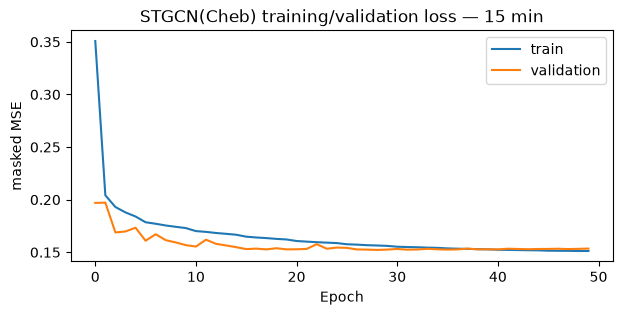

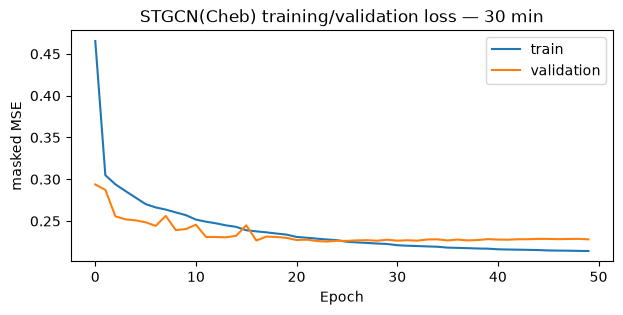

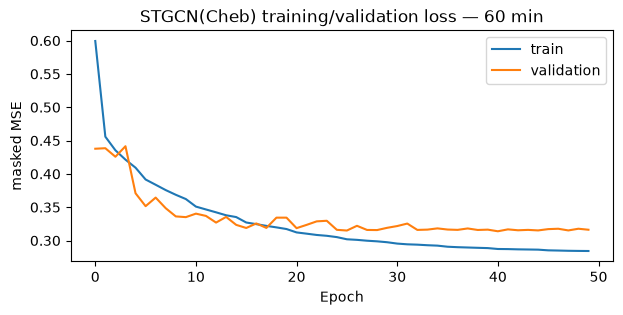

,Model,Horizon,MAE,RMSE,MAPE
0,STGCN(Cheb),15 min,3.052872,5.440707,7.899925
1,STGCN(Cheb),30 min,3.712885,6.641469,10.140462
2,STGCN(Cheb),60 min,4.570361,7.913755,12.912265


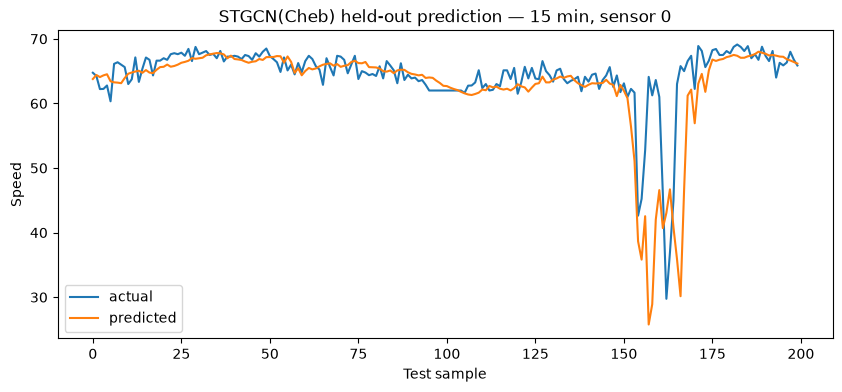

Saved results/stgcn_model_comparison.csv


In [16]:
if RUN_TRAINING:
    records = []
    representative = None
    for horizon, (model, train_curve, val_curve) in stgcn_runs.items():
        test_loader, _ = make_loader("test", horizon, STGCN_BATCH_SIZE, False)
        _, pred, target, mask = evaluate_model(model, test_loader)
        metric = original_unit_metrics(pred, target, mask)
        records.append(
            {"Model": "STGCN(Cheb)", "Horizon": f"{horizon * 5} min", **metric}
        )
        if representative is None:
            representative = (pred, target, mask, horizon)
        plt.figure(figsize=(7, 3))
        plt.plot(train_curve, label="train")
        plt.plot(val_curve, label="validation")
        plt.title(f"STGCN(Cheb) training/validation loss — {horizon * 5} min")
        plt.xlabel("Epoch")
        plt.ylabel("masked MSE")
        plt.legend()
        plt.show()
    comparison = pd.DataFrame(
        records, columns=["Model", "Horizon", "MAE", "RMSE", "MAPE"]
    )
    display(comparison)
    comparison.to_csv(RESULTS_DIR / "stgcn_model_comparison.csv", index=False)
    pred, target, mask, horizon = representative
    sensor = int(np.flatnonzero(mask[0])[0])
    plt.figure(figsize=(10, 4))
    plt.plot(target[:200, sensor] * train_std + train_mean, label="actual")
    plt.plot(pred[:200, sensor] * train_std + train_mean, label="predicted")
    plt.title(f"STGCN(Cheb) held-out prediction — {horizon * 5} min, sensor {sensor}")
    plt.xlabel("Test sample")
    plt.ylabel("Speed")
    plt.legend()
    plt.show()
    print(f"Saved {RESULTS_DIR / 'stgcn_model_comparison.csv'}")
else:
    print(
        "RUN_TRAINING=False: set it to True to train STGCN(Cheb) at all three horizons."
    )